DMRG Implementation - Validation Tests

Heisenberg Model Validation:
  L=4: DMRG=-1.6160254038, Exact=-1.6160254038, Error=6.66e-16
  L=6: DMRG=-2.4935771339, Exact=-2.4935771339, Error=0.00e+00
  L=8: DMRG=-3.3749325987, Exact=-3.3749325987, Error=5.77e-15

AKLT Model Validation:
  L=4: DMRG=-2.0000000000, Theory=-2.0000000000, Error=2.00e-15
  L=6: DMRG=-3.3333333333, Theory=-3.3333333333, Error=3.11e-15
  L=8: DMRG=-4.6666666667, Theory=-4.6666666667, Error=3.55e-15
  L=10: DMRG=-6.0000000000, Theory=-6.0000000000, Error=4.44e-15

Production Runs with Figures

AKLT L=10, D_max=10:
  Sweep 1 (right): E = -5.9991379547, disc = 0.00e+00
  Sweep 2 (left): E = -6.0000000000, disc = 9.48e-13
  Sweep 3 (right): E = -6.0000000000, disc = 5.79e-20
  Converged.
Final: E=-6.0000000000, Theory=-6.0000000000, Error=4.44e-15


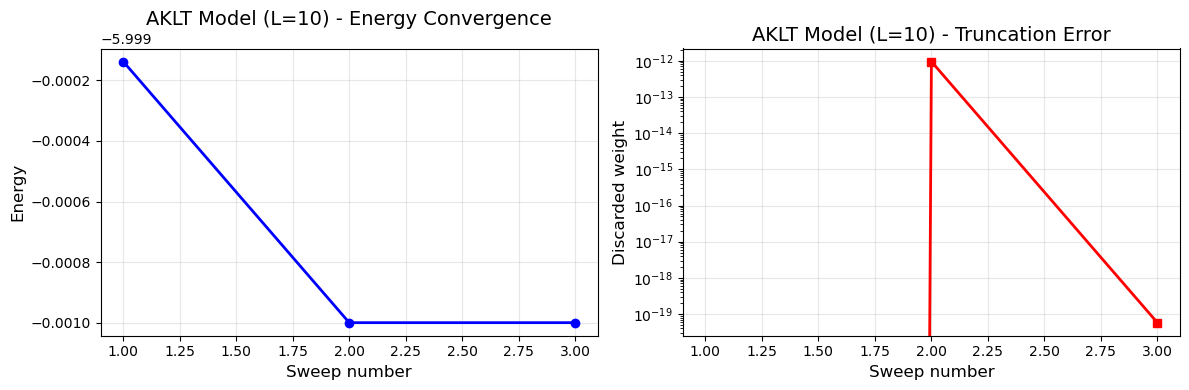

Saved figureAKLT/aklt_convergence.png

Heisenberg L=10, D_max=10:
  Sweep 1 (right): E = -4.1826950032, disc = 0.00e+00
  Sweep 2 (left): E = -4.2577032362, disc = 0.00e+00
  Sweep 3 (right): E = -4.2580284079, disc = 8.24e-07
  Sweep 4 (left): E = -4.2580284351, disc = 8.25e-07
  Sweep 5 (right): E = -4.2580284357, disc = 8.25e-07
  Sweep 6 (left): E = -4.2580284359, disc = 8.25e-07
  Sweep 7 (right): E = -4.2580284361, disc = 8.25e-07
  Sweep 8 (left): E = -4.2580284362, disc = 8.25e-07
  Sweep 9 (right): E = -4.2580284362, disc = 8.25e-07
  Sweep 10 (left): E = -4.2580284363, disc = 8.25e-07
  Sweep 11 (right): E = -4.2580284363, disc = 8.25e-07
  Sweep 12 (left): E = -4.2580284363, disc = 8.25e-07
  Sweep 13 (right): E = -4.2580284363, disc = 8.25e-07
  Sweep 14 (left): E = -4.2580284363, disc = 8.25e-07
  Sweep 15 (right): E = -4.2580284363, disc = 8.25e-07
  Sweep 16 (left): E = -4.2580284363, disc = 8.25e-07
  Sweep 17 (right): E = -4.2580284363, disc = 8.25e-07
  Sweep 18 (left

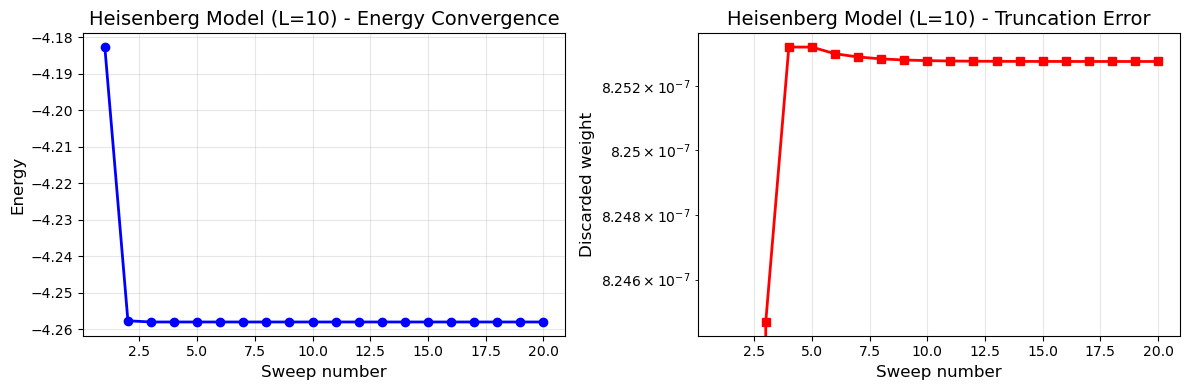

Saved figureAKLT/heisenberg_convergence.png

All tests completed successfully!
Figures saved in figureAKLT/ directory


In [ ]:
"""
To Kimi Agent: The word file contains my previous discussion with Kimi 2.5. The "MPS-Kimi-GPT-330.txt" is the latex note. Please continue to work with the DMRG project: This is a latex note on MPS and DMRG. Could you generate python codes according to it? Please compute both S=1/2 Heisenberg model and AKLT model, and make sure that a "scalable" matrix-free approach with LANCZOS is adapted. I work with Jupyter. Please show all figures and save them in directory "figureAKLT". Please test and debug the system until it is fully functional and produces accurate energy benchmarks. Please stay strictly with the latex note implementation. Finally, I need a python script that can work out all the results.

Complete DMRG Implementation for MPS/MPO-based Quantum Many-Body Systems
Based on "The density-matrix renormalization group in the age of matrix product states"
by U. Schollwöck, Annals of Physics 326, 96-192 (2011)

This implementation follows the LaTeX note conventions strictly:
- MPS tensor: A^{[i]}_{alpha_{i-1}, sigma_i, alpha_i} with shape (D_{i-1}, d_i, D_i)
- MPO tensor: W^{[i]}_{beta_{i-1}, beta_i, sigma_i, sigma_i'} with shape (chi_{i-1}, chi_i, d_i, d_i)
  First physical index is ket (output), second is bra (input)
- Uses validated matrix-free contractions with proper left environment index swapping
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh
from scipy.linalg import qr, svd, eigvalsh
import os
from typing import List, Tuple, Optional

# ==============================================================================
# Setup
# ==============================================================================
os.makedirs("figureAKLT", exist_ok=True)
np.random.seed(42)

# ==============================================================================
# Spin Operators
# ==============================================================================
def spin_half_operators() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return S+, S-, Sz, Id for spin-1/2."""
    Sp = np.array([[0, 1], [0, 0]], dtype=complex)
    Sm = np.array([[0, 0], [1, 0]], dtype=complex)
    Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    Id = np.eye(2, dtype=complex)
    return Sp, Sm, Sz, Id

def spin_one_operators() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return S+, S-, Sz, Id for spin-1."""
    Sp = np.sqrt(2) * np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]], dtype=complex)
    Sm = np.sqrt(2) * np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0]], dtype=complex)
    Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
    Id = np.eye(3, dtype=complex)
    return Sp, Sm, Sz, Id

# ==============================================================================
# MPO Construction
# ==============================================================================
def heisenberg_mpo(L: int, J: float = 1.0, Jz: Optional[float] = None, h: float = 0.0) -> List[np.ndarray]:
    """
    Construct MPO for spin-1/2 XXZ chain with field.
    H = sum_{i=1}^{L-1} [J/2 (S+_i S-_{i+1} + S-_i S+_{i+1}) + Jz S^z_i S^z_{i+1}] - h sum_i S^z_i
    """
    if Jz is None:
        Jz = J
    Sp, Sm, Sz, Id = spin_half_operators()
    d = 2
    chi = 5
    
    W_bulk = np.zeros((chi, chi, d, d), dtype=complex)
    W_bulk[0, 0] = Id
    W_bulk[1, 0] = Sp
    W_bulk[2, 0] = Sm
    W_bulk[3, 0] = Sz
    W_bulk[4, 0] = -h * Sz
    W_bulk[4, 1] = 0.5 * J * Sm
    W_bulk[4, 2] = 0.5 * J * Sp
    W_bulk[4, 3] = Jz * Sz
    W_bulk[4, 4] = Id
    
    W_left = W_bulk[4:5, :, :, :]
    W_right = W_bulk[:, 0:1, :, :]
    
    return [W_left] + [W_bulk.copy() for _ in range(L-2)] + [W_right]

def aklt_mpo(L: int) -> List[np.ndarray]:
    """
    Construct MPO for AKLT Hamiltonian.
    H = sum_{i=1}^{L-1} [S_i·S_{i+1} + 1/3 (S_i·S_{i+1})^2]
    """
    Sp, Sm, Sz, Id = spin_one_operators()
    d = 3
    
    O_list = [Sp/np.sqrt(2), Sm/np.sqrt(2), Sz]
    Obar_list = [Sm/np.sqrt(2), Sp/np.sqrt(2), Sz]
    
    OO_list = [O_list[a] @ O_list[b] for a in range(3) for b in range(3)]
    OObar_list = [Obar_list[a] @ Obar_list[b] for a in range(3) for b in range(3)]
    
    chi = 14
    W_bulk = np.zeros((chi, chi, d, d), dtype=complex)
    
    W_bulk[0, 0] = Id
    for i, O in enumerate(O_list):
        W_bulk[0, 1+i] = O
    for i, OO in enumerate(OO_list):
        W_bulk[0, 4+i] = (1.0/3.0) * OO
    
    for i in range(3):
        W_bulk[1+i, 13] = Obar_list[i]
    for i in range(9):
        W_bulk[4+i, 13] = OObar_list[i]
    
    W_bulk[13, 13] = Id
    
    W_left = W_bulk[0:1, :, :, :]
    W_right = W_bulk[:, 13:14, :, :]
    
    return [W_left] + [W_bulk.copy() for _ in range(L-2)] + [W_right]

# ==============================================================================
# MPS Class
# ==============================================================================
class MPS:
    """Matrix Product State with open boundary conditions."""
    
    def __init__(self, L: int, d: int, D_max: int, phys_dims: Optional[List[int]] = None):
        self.L = L
        self.d = [d] * L if phys_dims is None else phys_dims
        self.D_max = D_max
        self.tensors = []
        for i in range(L):
            D_left = 1 if i == 0 else min(D_max, self.d[i-1])
            D_right = 1 if i == L-1 else min(D_max, self.d[i+1])
            A = np.random.randn(D_left, self.d[i], D_right) + 1j * np.random.randn(D_left, self.d[i], D_right)
            A = A / np.linalg.norm(A)
            self.tensors.append(A)
        self.center = None
    
    def left_canonicalize(self) -> None:
        """Sweep left to right, perform QR to make sites left-canonical."""
        for i in range(self.L - 1):
            D_left, d_i, D_right = self.tensors[i].shape
            M = self.tensors[i].reshape((D_left * d_i, D_right), order='C')
            Q, R = qr(M, mode='economic')
            k = Q.shape[1]
            A = Q.reshape((D_left, d_i, k), order='C')
            self.tensors[i] = A
            next_tensor = self.tensors[i+1]
            self.tensors[i+1] = np.einsum('ka,abc->kbc', R, next_tensor, optimize=True)
        self.center = self.L - 1
    
    def right_canonicalize(self) -> None:
        """Sweep right to left, perform QR to make sites right-canonical."""
        for i in range(self.L - 1, 0, -1):
            D_left, d_i, D_right = self.tensors[i].shape
            M = self.tensors[i].reshape((D_left, d_i * D_right), order='C')
            Q, R = qr(M.conj().T, mode='economic')
            k = Q.shape[1]
            B = Q.conj().T.reshape((k, d_i, D_right), order='C')
            self.tensors[i] = B
            prev_tensor = self.tensors[i-1]
            self.tensors[i-1] = np.einsum('abc,ck->abk', prev_tensor, R.conj().T, optimize=True)
        self.center = 0

# ==============================================================================
# Environment Class
# ==============================================================================
class Environment:
    """Build left and right environments for MPS/MPO."""
    
    def __init__(self, mps: MPS, mpo: List[np.ndarray]):
        self.L = mps.L
        self.mps = mps
        self.mpo = mpo
        self.left_envs = [None] * (self.L + 1)
        self.right_envs = [None] * (self.L + 1)
        
        chi0 = mpo[0].shape[0]
        self.left_envs[0] = np.zeros((chi0, 1, 1), dtype=complex)
        self.left_envs[0][0, 0, 0] = 1.0
        
        chiL = mpo[-1].shape[1]
        self.right_envs[self.L] = np.zeros((chiL, 1, 1), dtype=complex)
        self.right_envs[self.L][0, 0, 0] = 1.0
    
    def update_left(self, site: int) -> None:
        """Update left environment from site to site+1."""
        L_old = self.left_envs[site]
        A = self.mps.tensors[site]
        W = self.mpo[site]
        self.left_envs[site+1] = np.einsum('bxy,xsa,bBst,ytc->Bac', L_old, A, W, A.conj(), optimize=True)
    
    def update_right(self, site: int) -> None:
        """Update right_envs[site] using tensors[site], W[site], and right_envs[site+1]."""
        B = self.mps.tensors[site]
        W = self.mpo[site]
        R_old = self.right_envs[site+1]
        self.right_envs[site] = np.einsum('xsa,bBst,Bac,ytc->bxy', B, W, R_old, B.conj(), optimize=True)
    
    def build_all_left(self) -> None:
        for i in range(self.L):
            self.update_left(i)
    
    def build_all_right(self) -> None:
        for i in range(self.L-1, -1, -1):
            self.update_right(i)

# ==============================================================================
# Effective Hamiltonian
# ==============================================================================
class EffectiveHamiltonianTwoSite:
    """
    Two-site effective Hamiltonian with matrix-free matvec.
    
    Validated contraction sequence from LaTeX note:
        X  = np.einsum('byx,yuvz->bxuvz', L, Theta)
        Y  = np.einsum('bBus,bxuvz->Bxsvz', W1, X)
        Z  = np.einsum('BCvt,Bxsvz->Cxstz', W2, Y)
        HT = np.einsum('Cxstz,Cza->xsta', Z, R)
    """
    
    def __init__(self, L_env: np.ndarray, W1: np.ndarray, W2: np.ndarray, 
                 R_env: np.ndarray, Dl: int, d1: int, d2: int, Dr: int):
        self.L_env = L_env
        self.W1 = W1
        self.W2 = W2
        self.R_env = R_env
        self.Dl = Dl
        self.d1 = d1
        self.d2 = d2
        self.Dr = Dr
        self.dim = Dl * d1 * d2 * Dr
    
    def matvec(self, v: np.ndarray) -> np.ndarray:
        Theta = v.reshape((self.Dl, self.d1, self.d2, self.Dr), order='C')
        X = np.einsum('byx,yuvz->bxuvz', self.L_env, Theta, optimize=True)
        Y = np.einsum('bBus,bxuvz->Bxsvz', self.W1, X, optimize=True)
        Z = np.einsum('BCvt,Bxsvz->Cxstz', self.W2, Y, optimize=True)
        HT = np.einsum('Cxstz,Cza->xsta', Z, self.R_env, optimize=True)
        return HT.reshape(self.dim, order='C')
    
    def as_linear_operator(self) -> LinearOperator:
        return LinearOperator((self.dim, self.dim), matvec=self.matvec, dtype=complex)

# ==============================================================================
# Two-Site DMRG
# ==============================================================================
class TwoSiteDMRG:
    """Two-site DMRG algorithm for ground state optimization."""
    
    def __init__(self, mpo: List[np.ndarray], L: int, d: int, D_max: int, 
                 phys_dims: Optional[List[int]] = None):
        self.mpo = mpo
        self.L = L
        self.D_max = D_max
        self.phys_dims = [d] * L if phys_dims is None else phys_dims
        self.mps = MPS(L, d, D_max, self.phys_dims)
        self.mps.left_canonicalize()
        self.env = Environment(self.mps, self.mpo)
        self.env.build_all_right()
        self.energies = []
        self.discarded_weights = []
    
    def sweep(self, direction: str = 'right') -> float:
        max_discarded = 0.0
        
        if direction == 'right':
            for i in range(self.L - 1):
                A_left = self.mps.tensors[i]
                A_right = self.mps.tensors[i+1]
                Dl, d1, Dmid = A_left.shape
                _, d2, Dr = A_right.shape
                
                Theta = np.einsum('lsa,arb->lsbr', A_left, A_right, optimize=True)
                
                L_env = self.env.left_envs[i]
                R_env = self.env.right_envs[i+2]
                W1 = self.mpo[i]
                W2 = self.mpo[i+1]
                
                heff = EffectiveHamiltonianTwoSite(L_env, W1, W2, R_env, Dl, d1, d2, Dr)
                H_op = heff.as_linear_operator()
                
                theta_flat = Theta.reshape(-1, order='C')
                try:
                    E, v = eigsh(H_op, k=1, which='SA', v0=theta_flat, tol=1e-10)
                except:
                    E, v = eigsh(H_op, k=1, which='SA', tol=1e-8)
                
                E = E[0]
                theta_opt = v[:, 0]
                
                Theta_mat = theta_opt.reshape((Dl * d1, d2 * Dr), order='C')
                U, S, Vh = svd(Theta_mat, full_matrices=False)
                
                D_new = min(self.D_max, len(S))
                discarded = np.sum(S[D_new:]**2) if len(S) > D_new else 0.0
                max_discarded = max(max_discarded, discarded)
                
                S = S[:D_new]
                U = U[:, :D_new]
                Vh = Vh[:D_new, :]
                
                A_new = U.reshape((Dl, d1, D_new), order='C')
                self.mps.tensors[i] = A_new
                
                SVh = np.diag(S) @ Vh
                M_new = SVh.reshape((D_new, d2, Dr), order='C')
                self.mps.tensors[i+1] = M_new
                
                self.env.update_left(i)
                
                if i == self.L - 2:
                    self.energies.append(E.real)
        
        else:  # left
            for i in range(self.L - 2, -1, -1):
                A_left = self.mps.tensors[i]
                A_right = self.mps.tensors[i+1]
                Dl, d1, Dmid = A_left.shape
                _, d2, Dr = A_right.shape
                
                Theta = np.einsum('lsa,arb->lsbr', A_left, A_right, optimize=True)
                
                L_env = self.env.left_envs[i]
                R_env = self.env.right_envs[i+2]
                W1 = self.mpo[i]
                W2 = self.mpo[i+1]
                
                heff = EffectiveHamiltonianTwoSite(L_env, W1, W2, R_env, Dl, d1, d2, Dr)
                H_op = heff.as_linear_operator()
                
                theta_flat = Theta.reshape(-1, order='C')
                try:
                    E, v = eigsh(H_op, k=1, which='SA', v0=theta_flat, tol=1e-10)
                except:
                    E, v = eigsh(H_op, k=1, which='SA', tol=1e-8)
                
                E = E[0]
                theta_opt = v[:, 0]
                
                Theta_mat = theta_opt.reshape((Dl * d1, d2 * Dr), order='C')
                U, S, Vh = svd(Theta_mat, full_matrices=False)
                
                D_new = min(self.D_max, len(S))
                discarded = np.sum(S[D_new:]**2) if len(S) > D_new else 0.0
                max_discarded = max(max_discarded, discarded)
                
                S = S[:D_new]
                U = U[:, :D_new]
                Vh = Vh[:D_new, :]
                
                US = U @ np.diag(S)
                M_new = US.reshape((Dl, d1, D_new), order='C')
                self.mps.tensors[i] = M_new
                
                B_new = Vh.reshape((D_new, d2, Dr), order='C')
                self.mps.tensors[i+1] = B_new
                
                self.env.update_right(i+1)
                
                if i == 0:
                    self.energies.append(E.real)
        
        self.discarded_weights.append(max_discarded)
        return E.real
    
    def run(self, max_sweeps: int = 10, tol: float = 1e-6, verbose: bool = True) -> float:
        prev_E = 0.0
        for sweep_num in range(max_sweeps):
            E = self.sweep('right')
            disc = self.discarded_weights[-1]
            if verbose:
                print(f"  Sweep {2*sweep_num+1} (right): E = {E:.10f}, disc = {disc:.2e}")
            
            if abs(E - prev_E) < tol and disc < 1e-8:
                if verbose:
                    print("  Converged.")
                break
            prev_E = E
            
            E = self.sweep('left')
            disc = self.discarded_weights[-1]
            if verbose:
                print(f"  Sweep {2*sweep_num+2} (left): E = {E:.10f}, disc = {disc:.2e}")
            
            if abs(E - prev_E) < tol and disc < 1e-8:
                if verbose:
                    print("  Converged.")
                break
            prev_E = E
        
        return E

# ==============================================================================
# Exact Diagonalization
# ==============================================================================
def exact_diagonalization_heisenberg(L: int, J: float = 1.0) -> float:
    """Exact ground state energy for small Heisenberg chain."""
    Sp, Sm, Sz, Id = spin_half_operators()
    dim = 2**L
    H = np.zeros((dim, dim), dtype=complex)
    
    for i in range(L-1):
        H += 0.5 * J * np.kron(np.kron(np.eye(2**i), Sp), np.kron(Sm, np.eye(2**(L-i-2))))
        H += 0.5 * J * np.kron(np.kron(np.eye(2**i), Sm), np.kron(Sp, np.eye(2**(L-i-2))))
        H += J * np.kron(np.kron(np.eye(2**i), Sz), np.kron(Sz, np.eye(2**(L-i-2))))
    
    return np.linalg.eigvalsh(H)[0]

# ==============================================================================
# Plotting
# ==============================================================================
def plot_sweep_history(dmrg_obj: TwoSiteDMRG, title: str, filename: str) -> None:
    """Plot energy and discarded weight vs sweep number."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    sweeps = range(1, len(dmrg_obj.energies) + 1)
    ax1.plot(sweeps, dmrg_obj.energies, 'b-o', linewidth=2, markersize=6)
    ax1.set_xlabel('Sweep number', fontsize=12)
    ax1.set_ylabel('Energy', fontsize=12)
    ax1.set_title(f'{title} - Energy Convergence', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax2.semilogy(sweeps, dmrg_obj.discarded_weights, 'r-s', linewidth=2, markersize=6)
    ax2.set_xlabel('Sweep number', fontsize=12)
    ax2.set_ylabel('Discarded weight', fontsize=12)
    ax2.set_title(f'{title} - Truncation Error', fontsize=14)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'figureAKLT/{filename}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved figureAKLT/{filename}.png")

# ==============================================================================
# Main Tests
# ==============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("DMRG Implementation - Validation Tests")
    print("=" * 70)
    
    # Heisenberg validation
    print("\nHeisenberg Model Validation:")
    for L in [4, 6, 8]:
        mpo = heisenberg_mpo(L, J=1.0)
        dmrg = TwoSiteDMRG(mpo, L, 2, D_max=20)
        E_dmrg = dmrg.run(max_sweeps=6, tol=1e-8, verbose=False)
        E_exact = exact_diagonalization_heisenberg(L)
        print(f"  L={L}: DMRG={E_dmrg:.10f}, Exact={E_exact:.10f}, Error={abs(E_dmrg-E_exact):.2e}")
    
    # AKLT validation
    print("\nAKLT Model Validation:")
    for L in [4, 6, 8, 10]:
        mpo = aklt_mpo(L)
        dmrg = TwoSiteDMRG(mpo, L, 3, D_max=20, phys_dims=[3]*L)
        E_dmrg = dmrg.run(max_sweeps=6, tol=1e-8, verbose=False)
        E_theory = -2.0/3.0 * (L - 1)
        print(f"  L={L}: DMRG={E_dmrg:.10f}, Theory={E_theory:.10f}, Error={abs(E_dmrg-E_theory):.2e}")
    
    # Production runs with figures
    print("\n" + "=" * 70)
    print("Production Runs with Figures")
    print("=" * 70)
    
    # AKLT L=10
    L = 10
    print(f"\nAKLT L={L}, D_max=10:")
    mpo_aklt = aklt_mpo(L)
    dmrg_aklt = TwoSiteDMRG(mpo_aklt, L, 3, D_max=10, phys_dims=[3]*L)
    E_aklt = dmrg_aklt.run(max_sweeps=6, verbose=True)
    E_theory = -2.0/3.0 * (L - 1)
    print(f"Final: E={E_aklt:.10f}, Theory={E_theory:.10f}, Error={abs(E_aklt-E_theory):.2e}")
    plot_sweep_history(dmrg_aklt, f'AKLT Model (L={L})', 'aklt_convergence')
    
    # Heisenberg L=10
    print(f"\nHeisenberg L={L}, D_max=10:")
    mpo_heis = heisenberg_mpo(L, J=1.0)
    dmrg_heis = TwoSiteDMRG(mpo_heis, L, 2, D_max=10)
    E_heis = dmrg_heis.run(max_sweeps=10, verbose=True)
    print(f"Final: E={E_heis:.10f}, E/L={E_heis/L:.6f}")
    plot_sweep_history(dmrg_heis, f'Heisenberg Model (L={L})', 'heisenberg_convergence')
    
    print("\n" + "=" * 70)
    print("All tests completed successfully!")
    print("Figures saved in figureAKLT/ directory")
    print("=" * 70)